#### Wasserstein GAN with Gradient Penalty
https://arxiv.org/abs/1704.00028


In [9]:
# import libraries
import os
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision.utils import make_grid,save_image

import matplotlib.pyplot as plt
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [10]:
path = os.path.join(os.getcwd(), 'data', 'augmented_animals')
mean = torch.tensor([0.50869316, 0.50057036, 0.44047505]) # Calculated for the given dataset
std = torch.tensor([0.20191325, 0.19737212, 0.20100889]) # Calculated for the given dataset

# Architecture parameters
image_size = 128
batch_size = 64
generator_features = 64
latent_size = 100
discriminator_features = 64
n_workers = 8

transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])
data = ImageFolder(path, transform=transform)
loader = DataLoader(data, batch_size=batch_size, shuffle=True, num_workers= n_workers)

In [11]:
class generator(nn.Module):
    def __init__(self, latent_size, image_size, generator_features):
        super(generator, self).__init__()
        self.latent_size = latent_size
        self.image_size = image_size
        self.generator_features = generator_features
        self.main = nn.Sequential(
            self.generator_block(latent_size, generator_features * 16, 4, 1, 0), # generator_features*8 x 4 x 4
            self.generator_block(generator_features * 16, generator_features * 8, 4, 2, 1), # generator_features*4 x 8 x 8
            self.generator_block(generator_features * 8, generator_features * 4, 4, 2, 1), # generator_features*2 x 16 x 16
            self.generator_block(generator_features * 4, generator_features * 2, 4, 2, 1),    # generator_features x 32 x 32
            self.generator_block(generator_features * 2, generator_features, 4, 2, 1),    # generator_features x 64 x 64
            nn.ConvTranspose2d(generator_features, 3, 4, 2, 1), # 3 x 128 x 128
            nn.Tanh()
        )
    def forward(self, x):
        return self.main(x)
    def generator_block(self, in_channels, out_channels, kernel_size, stride, padding):
        return nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size, stride, padding),
            nn.BatchNorm2d(out_channels),
            nn.ReLU()
        )

class discriminator(nn.Module):
    def __init__(self, discriminator_features):
        super(discriminator, self).__init__()
        self.discriminator_features = discriminator_features
        self.main = nn.Sequential(
            self.discriminator_block(3, discriminator_features, 4, 2, 1), # discriminator_features x 64 x 64
            self.discriminator_block(discriminator_features, discriminator_features * 2, 4, 2, 1), # discriminator_features*2 x 32 x 32
            self.discriminator_block(discriminator_features * 2, discriminator_features * 4, 4, 2, 1), # discriminator_features*4 x 16 x 16
            self.discriminator_block(discriminator_features * 4, discriminator_features * 8, 4, 2, 1), # discriminator_features*8 x 8 x 8
            self.discriminator_block(discriminator_features * 8, discriminator_features * 16, 4, 2, 1), # discriminator_features*16 x 4 x 4
            nn.Conv2d(discriminator_features * 16, 1, 4, 1, 0), # 1 x 1 x 1
            # Sigmoid is not needed in WGAN
        )
    def forward(self, x):
        return self.main(x)
    def discriminator_block(self, in_channels, out_channels, kernel_size, stride, padding):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2)
        )
    
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)
def gradient_penalty(critic, real, fake,device):
    N, C, H, W = real.shape
    epsilon = torch.rand((N, 1, 1, 1)).repeat(1, C, H, W).to(device)
    interpolated_images = real * epsilon + fake * (1 - epsilon)
    mixed_scores = critic(interpolated_images)
    gradient = torch.autograd.grad(
        inputs=interpolated_images,
        outputs=mixed_scores,
        grad_outputs=torch.ones_like(mixed_scores),
        create_graph=True,
        retain_graph=True,
    )[0]
    gradient = gradient.view(gradient.shape[0], -1)
    gradient_norm = gradient.norm(2, dim=1)
    gradient_penalty = torch.mean((gradient_norm - 1) ** 2)
    return gradient_penalty

def test():
    N, in_channels, H, W = 64, 3, 128, 128
    x = torch.randn((N, in_channels, H, W)).to(device)  # 64,3,128,128
    D = discriminator(discriminator_features).to(device)
    assert D(x).shape == (N, 1, 1, 1), "Critic test failed"

    G = generator(latent_size, image_size, generator_features).to(device)
    z = torch.randn((N, latent_size, 1, 1)).to(device)
    assert G(z).shape == (N, in_channels, H, W), "Generator test failed"
    print("All architectural tests passed")
test()

All architectural tests passed


In [12]:
# Training parameters
num_epochs = 100
lr = 1e-4
beta1 = 0
beta2 = 0.9
n_critic = 5
lambda_gp = 10

G = generator(latent_size, image_size, generator_features).to(device)
D = discriminator(discriminator_features).to(device)

G.apply(weights_init)
D.apply(weights_init)

D_optim = optim.Adam(D.parameters(), lr=lr, betas=(beta1, beta2))
G_optim = optim.Adam(G.parameters(), lr=lr, betas=(beta1, beta2))

D_loss = []
G_loss = []

fixed_noise = torch.randn(batch_size, latent_size, 1, 1).to(device)

os.makedirs('wgangp_output', exist_ok=True)

for i in range(num_epochs):
    for j, (real, _) in enumerate(loader):

        for _ in range(n_critic):
            real = real.to(device)
            real = real.requires_grad_(True)

            noise = torch.randn(real.shape[0], latent_size, 1, 1).to(device)
            fake = G(noise)
            fake = fake.requires_grad_(True)

            D_real = D(real).view(-1)
            D_fake = D(fake).view(-1)

            loss_D = - (D_real.mean() - D_fake.mean()) + lambda_gp * gradient_penalty(D, real, fake, device)


            D.zero_grad()
            loss_D.backward()
            D_optim.step()


        noise = torch.randn(batch_size, latent_size, 1, 1).to(device)
        fake = G(noise)
        fake = fake.requires_grad_(True)
        D_fake = D(fake).view(-1)
        loss_G = - D_fake.mean()

        G.zero_grad()
        loss_G.backward()
        G_optim.step()

        if j % 100 == 0:
            print(f'Epoch {i}/{num_epochs}, Step {j}/{len(loader)}, Loss D: {loss_D.item():.5f}, Loss G: {loss_G.item():.5f}')
            D_loss.append(loss_D.item())
            G_loss.append(loss_G.item())
            with torch.no_grad():
                    fake_images = G(fixed_noise).detach().cpu()
                    save_image(make_grid(fake_images,nrow=8, padding=2, normalize=True), f'wgangp_output/{i}_{j}.png', normalize=True)

torch.save(G, 'wgangp_generator.pth')

Epoch 0/100, Step 0/254, Loss D: 21.46567, Loss G: 8.09228
Epoch 0/100, Step 100/254, Loss D: -1015.80432, Loss G: 530.34723
Epoch 0/100, Step 200/254, Loss D: -2114.63721, Loss G: 1074.70508
Epoch 1/100, Step 0/254, Loss D: -3.91763, Loss G: -1322.29810
Epoch 1/100, Step 100/254, Loss D: -4040.87573, Loss G: 2052.43726
Epoch 1/100, Step 200/254, Loss D: -5146.46436, Loss G: 2596.26367
Epoch 2/100, Step 0/254, Loss D: -347.74518, Loss G: -1841.42737
Epoch 2/100, Step 100/254, Loss D: -276.90005, Loss G: -1865.78735
Epoch 2/100, Step 200/254, Loss D: -970.26105, Loss G: -242.47787
Epoch 3/100, Step 0/254, Loss D: -218.10144, Loss G: -1796.22974
Epoch 3/100, Step 100/254, Loss D: -214.74733, Loss G: -1370.07483
Epoch 3/100, Step 200/254, Loss D: -2110.03760, Loss G: -343.44943
Epoch 4/100, Step 0/254, Loss D: 37.47431, Loss G: 59.33289
Epoch 4/100, Step 100/254, Loss D: -3300.73657, Loss G: 3331.63916
Epoch 4/100, Step 200/254, Loss D: -1517.50989, Loss G: 4448.08301
Epoch 5/100, Step 0/

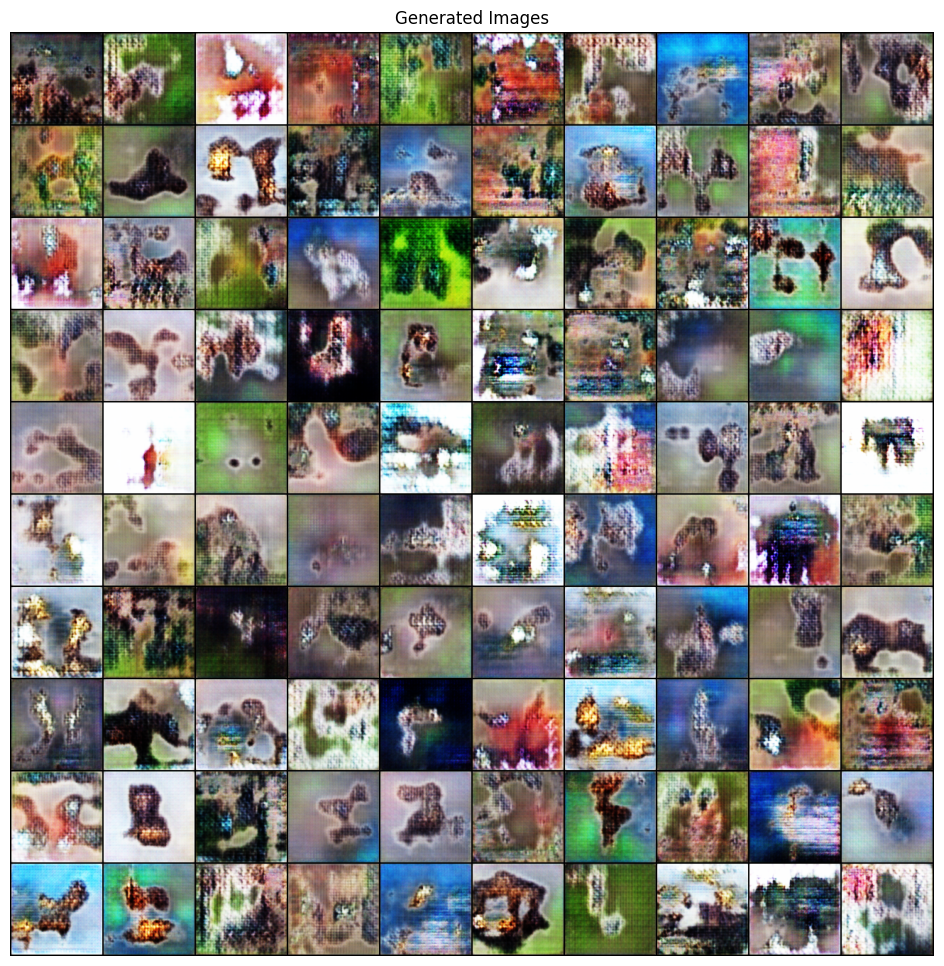

In [28]:
# plt.plot(D_loss, label='Discriminator Loss')
# plt.plot(G_loss, label='Generator Loss')
# plt.legend()
# plt.show()

# Generate images
G = torch.load('wgan_generator.pth',weights_only=False)
fixed_noise = torch.randn(100, latent_size, 1, 1).to(device)
generated = G(fixed_noise)
plt.figure(figsize=(12,12))
plt.axis("off")
plt.title("Generated Images")
plt.imshow(make_grid(generated.detach().cpu(), nrow=10, padding=2, normalize=True).permute(1, 2, 0))
plt.show()



FID Calculation

In [27]:
import numpy as np
fake_images = []

for i in range(1000):
    noise = torch.randn(1, latent_size, 1, 1).to(device)
    img = G(noise).detach().cpu().numpy().squeeze()
    # 0 to 1 normalization
    img = (img - img.min()) / (img.max() - img.min())
    fake_images.append(img)
fake_images = np.array(fake_images)
# 1000 real fake_images in tensor format
real_images = []
for i in range(1000):
    img, _ = data[i]
    # 0 to 1 normalization
    img = (img.numpy() - img.numpy().min()) / (img.numpy().max() - img.numpy().min())
    real_images.append(img)
real_images = np.array(real_images)

import torch
from torcheval.metrics import FrechetInceptionDistance


# Initialize FID metric calculator
fid_metric = FrechetInceptionDistance(feature_dim=2048)  # FID is typically computed using Inception-V3 features with 2048 dimensions
# normalize the images

# Update the FID metric with real and fake images
fid_metric.update(torch.tensor(real_images), is_real=True)
fid_metric.update(torch.tensor(fake_images), is_real=False)

# Compute the FID score
fid_score = fid_metric.compute()

print(f"FID Score: {fid_score.item()}")

FID Score: 227.51007080078125


Q7 Learning/Observation:

Generated Image are less clearer than Vanilla GAN but this may be because WGAN is slow learner and it need more epochs for better visuals. \
Other than that We quickly Got a Stable Training in both WGAN experiments.

##### Why WGAN/WGAN-GP is slow Learner?
May be because of Weight clipping and Gradient clipping it restricts gradients. \
Critic is trained more often which may make it stronger than generator and also contribute to slow learning than vanila GAN




Question 7 is over here